# 3. Machine Learning for Classification

We'll use logistic regression to predict churn


## 3.1 Churn prediction project

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


## 3.2 Data preparation

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if all the columns read correctly
* Check if the churn variable needs any preparation

In [268]:
# import: 다른 사람이 만든 도구(라이브러리)를 이 노트북으로 불러오는 문법이다.
# pandas는 행과 열이 있는 표 데이터를 다루는 라이브러리다.
# as pd 는 앞으로 pandas 대신 짧은 이름 pd 를 쓰겠다는 뜻이다.
# 예: pd.read_csv(), pd.DataFrame()
import pandas as pd

# numpy는 숫자 배열·행렬 계산용 라이브러리다. as np 로 짧게 부른다.
# pandas 표 안의 숫자 열, 나중에 모델이 받는 배열(X, y)이 numpy와 연결된다.
import numpy as np

# matplotlib.pyplot은 그래프를 그릴 때 쓴다. as plt 로 부른다.
# 아래에서 시그모이드 곡선을 plt.plot() 으로 그릴 때 필요하다.
import matplotlib.pyplot as plt

# sklearn(사이킷런)은 머신러닝 모델·전처리·평가 도구 모음이다.
# set_config는 sklearn이 화면에 모델을 어떻게 보여줄지 바꾸는 함수다.
from sklearn import set_config

# display="text": 모델 미리보기를 HTML이 아니라 글자로만 보여 준다.
# 한국어 Windows(cp949)에서 sklearn 1.9 HTML이 깨지는 것을 막기 위해 필요하다.
# 데이터를 바꾸지는 않는다. 출력 방식만 바뀐다.
set_config(display="text")


In [269]:
# 웹에 올라 있는 CSV 주소를 문자열로 변수 data 에 담는다.
# 이 데이터는 통신사 고객이 서비스를 해지할지(churn)를 예측하는 데 쓰인다.
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'


In [270]:
# pathlib.Path: 파일 경로를 OS에 맞게 다루는 도구다. 경로를 문자열로만 쓰면 실수하기 쉽다.
from pathlib import Path
# urllib.request: 인터넷에서 파일을 받을 때 쓰는 표준 라이브러리 모듈이다.
# 강의 원본의 !wget 은 리눅스용이라, Windows에서는 이 모듈을 쓴다.
import urllib.request

# 받을 파일을 노트북 폴더에 data-week-3.csv 라는 이름으로 두겠다는 뜻이다.
csv_path = Path('data-week-3.csv')
# exists(): 그 파일이 이미 있는지 확인할 때 쓴다. 있으면 다시 안 받는다.
if not csv_path.exists():
    # urlretrieve(주소, 저장경로): URL의 파일을 로컬 디스크로 복사할 때 쓴다.
    # 실행 후 노트북 폴더에 CSV가 생긴다. 표(df)는 아직 안 만들어진다.
    urllib.request.urlretrieve(data, csv_path)
# resolve(): 상대 경로를 절대 경로로 바꿔 보여 준다. 파일이 어디에 있는지 확인할 때 쓴다.
print(csv_path.resolve())


E:\IT_SPACES\AI\ZoomCamp\ML\03\classification\notebook\data-week-3.csv


In [271]:
# pd.read_csv(파일명): CSV를 읽어서 pandas DataFrame으로 만들 때 쓴다.
# DataFrame은 파이썬에서 다루는 '엑셀 표'라고 생각하면 된다. 행=고객, 열=특성.
# 읽은 표 전체를 변수 df 에 저장한다. 이후 전처리·학습은 이 df 로 한다.
df = pd.read_csv('data-week-3.csv')
# head(): 앞 몇 행만 미리 볼 때 쓴다. 열이 많은지, 값이 어떻게 생겼는지 첫 점검이다.
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [272]:
# df.columns: 표의 모든 열 이름이다. 예: customerID, Monthly Charges, ...
# .str 은 '열 이름들이 문자열이라 문자열 메서드를 쓰겠다'는 뜻이다.
# .str.lower(): 대문자를 소문자로 바꿀 때. Monthly Charges → monthly charges
# .str.replace(' ', '_'): 공백을 밑줄로 바꿀 때. monthly charges → monthly_charges
# 왜 필요한가: 공백 있는 열 이름은 df.monthly charges 처럼 점(.)으로 접근이 안 된다.
# 실행 후 열 이름만 바뀌고, 안의 숫자는 그대로다.
df.columns = df.columns.str.lower().str.replace(' ', '_')

# select_dtypes: 지정한 자료형인 열만 고를 때 쓴다.
# object = 예전 pandas의 문자열, string = pandas 3의 문자열.
# 둘 다 고르지 않으면 범주형 열이 빠져 'Yes'/'No' 통일이 안 된다.
categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)

# 각 문자열 열의 '값'도 소문자+밑줄로 통일한다.
# Yes/yes 가 섞이면 모델이 다른 범주로 본다.
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')


In [273]:
# .T (transpose): 행과 열을 뒤집을 때 쓴다.
# 열이 많으면 head()만 보면 가로로 잘리므로, 열 이름과 샘플 값을 세로로 볼 때 쓴다.
df.head().T


,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [274]:
# pd.to_numeric: 글자로 읽힌 값을 숫자로 바꿀 때 쓴다.
# TotalCharges는 원래 숫자인데, 빈칸이 공백 문자열이면 문자 열로 읽힌다.
# errors='coerce': 숫자로 못 바꾸면 에러 대신 NaN(결측)으로 만들 때 쓴다.
# 결과는 tc 에만 들어가고, 아직 df.totalcharges 원본은 안 바뀐다. (다음 셀에서 덮어쓴다)
tc = pd.to_numeric(df.totalcharges, errors='coerce')


In [275]:
tc

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [276]:
# 시험 변환을 실제 열에 적용한다. 성공한 칸은 float, 실패한 칸(공백)은 NaN.
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')


In [277]:
df.totalcharges

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [278]:
# fillna(0): 결측(NaN)을 0으로 채울 때 쓴다.
# 가입 당월(tenure=0) 고객은 아직 청구액이 없어서 칸이 비어 있는 경우가 많다.
# '청구된 적 없음 = 0원'으로 해석한다. 숫자 열이 완성되어야 모델에 넣을 수 있다.
df.totalcharges = df.totalcharges.fillna(0)


In [279]:
# 타깃 열 churn 의 앞부분을 본다. 지금은 'yes'/'no' 문자열이다.
# Series.head(): 한 열의 앞 몇 값만 볼 때 쓴다. DataFrame.head()와 같지만 열이 하나다.
df.churn.head()


0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [280]:
# 머신러닝 분류 모델은 타깃(target)을 숫자로 쓰는 편이 편하다.
# 지금 churn 은 'yes'/'no' 문자열이다.
#
# df.churn == 'yes'  → yes면 True, no면 False (불리언 Series)
# .astype(int)       → True는 1, False는 0
#
# yes → 1 : 이탈했다
# no  → 0 : 이탈하지 않았다
# 이게 이 프로젝트의 target variable 이다.
df.churn = (df.churn == 'yes').astype(int)

## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [281]:
# train_test_split: 표를 무작위로 여러 덩어리로 나눌 때 쓰는 sklearn 함수다.
# 모델을 '연습(train) / 점검(validation) / 최종시험(test)'에 쓰기 위해 나눈다.
# 한 데이터로 배우고 같은 데이터로 채점하면 점수가 과하게 좋게 나온다.
from sklearn.model_selection import train_test_split


In [282]:
# 1단계: 전체의 20%를 테스트로 떼어 둔다. 테스트는 맨 마지막에만 본다.
# random_state=1: 난수 씨앗. 같은 숫자면 다시 실행해도 같은 행이 테스트로 간다.
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

# 2단계: 남은 80%(df_full_train)에서 25%를 validation 으로 뗀다.
# 전체=100이면 full_train=80, val=80*0.25=20, train=60.
# 최종 비율: train 60% / validation 20% / test 20%.
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)


In [283]:
# len(): 행 개수. 세 세트의 합이 전체와 같고, 대략 60:20:20인지 확인할 때 쓴다.
len(df_train), len(df_val), len(df_test)


(4225, 1409, 1409)

In [284]:
# reset_index(drop=True): 행 번호를 0,1,2...로 다시 매길 때 쓴다.
# split 후에는 원래 행 번호가 뒤섞여 남아 있다. drop=True는 옛 번호 열을 버린다.
# 데이터 값은 그대로이고, 인덱스만 깔끔해진다.
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [285]:
# .values: pandas Series를 numpy 배열로 꺼낼 때 쓴다.
# y(타깃)는 모델이 맞혀야 할 정답이다. X(특성)와 짝을 이룬다.
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

# del df['churn']: 특성 표에서 정답 열을 지운다.
# 입력 X에 정답이 남아 있으면 모델이 답을 보고 맞히는 target leakage(정보 누수)가 된다.
del df_train['churn']
del df_val['churn']
del df_test['churn']


## 3.4 EDA

* Check missing values
* Look at the target variable (churn)
* Look at numerical and categorical variables

In [286]:
# EDA(탐색)는 테스트는 보지 않고, train+val을 합친 df_full_train 으로 한다.
# 테스트로 탐색하면 '최종 시험 문제'를 미리 보는 셈이라 평가가 낙관적으로 왜곡된다.
df_full_train = df_full_train.reset_index(drop=True)


In [287]:
# isnull(): 칸이 비었는지(NaN) True/False로 표시할 때 쓴다.
# .sum(): 열마다 True 개수 = 결측 개수. 모델에 넣기 전 빈칸이 있는지 볼 때 쓴다.
df_full_train.isnull().sum()


customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [288]:
# value_counts: 값별로 몇 명인지 셀 때 쓴다.
# normalize=True 면 명수가 아니라 비율(0~1)이다.
# 이탈(1)이 적으면 accuracy만 보고 '다 유지로 찍어도 점수 좋음'에 속지 않으려고 본다.
df_full_train.churn.value_counts(normalize=True)


churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [289]:
# .mean(): 평균. churn이 0/1이면 평균 = 이탈한 사람 비율 = global churn(전체 이탈률).
# 이후 '여성 이탈률 - 전체'처럼 그룹과 비교할 기준값이다.
df_full_train.churn.mean()


np.float64(0.26996805111821087)

In [290]:
# numerical: 숫자 그대로 모델에 넣을 특성. 가입개월, 월요금, 총요금.
# categorical(범주)과 달리 원-핫으로 쪼개지 않는다.
numerical = ['tenure', 'monthlycharges', 'totalcharges']


In [291]:
# categorical: 값이 몇 가지 선택지인 특성(요금제, 성별, 결제수단 등).
# 모델은 'month-to-month' 같은 글자를 바로 못 쓰므로 나중에 원-핫으로 0/1 열을 만든다.
# seniorcitizen은 이미 0/1 숫자지만, 이 강의에서는 범주 목록에 넣는다.
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]


In [292]:
# nunique(): 그 열에 서로 다른 값이 몇 종류인지. 원-핫하면 열이 그만큼 늘어난다.
df_full_train[categorical].nunique()


gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.5 Feature importance: Churn rate and risk ratio

Feature importance analysis (part of EDA) - identifying which features affect our target variable

* Churn rate
* Risk ratio
* Mutual information - later

#### Churn rate

In [293]:
# 그룹별 이탈률을 계산하기 전에 표 모양을 다시 확인한다.
df_full_train.head()



,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [294]:
# df[조건]: 조건이 True인 행만 남긴다. gender == 'female' 인 고객만.
# .churn.mean(): 그 그룹의 이탈 비율. 전체(global churn)와 비교해 특성이 쓸모있는지 본다.
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female


np.float64(0.27682403433476394)

In [295]:
# 같은 방식으로 남성 그룹 이탈률. 여성과 거의 같으면 gender는 약한 신호다.
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male


np.float64(0.2632135306553911)

In [296]:
# global churn: 전체 고객의 이탈률. 그룹 이탈률을 판단하는 기준선이다.
global_churn = df_full_train.churn.mean()
global_churn


np.float64(0.26996805111821087)

In [297]:
# 전체 - 여성. 0에 가까우면 여성 이탈률 ≈ 전체, 즉 성별로 이탈이 갈리지 않는다.
global_churn - churn_female


np.float64(-0.006855983216553063)

In [298]:
# 전체 - 남성. gender 차이는 작아서 나중에 mutual information도 거의 0이 나온다.
global_churn - churn_male


np.float64(0.006754520462819769)

In [299]:
# partner 열의 yes/no 가 각각 몇 명인지. 그룹 비교 전에 표본 크기를 본다.
df_full_train.partner.value_counts()


partner
no     2932
yes    2702
Name: count, dtype: int64

In [300]:
# 배우자/파트너가 있는 고객의 이탈률. gender보다 전체와 차이가 큰지 본다.
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner


np.float64(0.20503330866025166)

In [301]:
# 양수면 이 그룹은 전체보다 이탈이 낮다(배우자가 있으면 더 남는 편).
global_churn - churn_partner


np.float64(0.06493474245795922)

In [302]:
# 파트너가 없는 고객의 이탈률. 위와 방향이 반대인지 확인한다.
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner


np.float64(0.3298090040927694)

In [303]:
# 음수면 이 그룹은 전체보다 이탈이 높다.
global_churn - churn_no_partner


np.float64(-0.05984095297455855)

#### Risk ratio

In [304]:
# risk ratio(위험비) = 그룹 이탈률 / 전체 이탈률.
# 1보다 크면 그 그룹은 평균보다 이탈 위험이 높다. 파트너 없음은 보통 > 1.
churn_no_partner / global_churn


np.float64(1.2216593879412643)

In [305]:
# 1보다 작으면 평균보다 안전. 파트너 있음은 보통 < 1.
churn_partner / global_churn


np.float64(0.7594724924338315)

```
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;
```

In [306]:
# display: 노트북에서 DataFrame을 표 모양으로 보여줄 때 쓴다. print()는 글자로 깨져 보인다.
from IPython.display import display


In [307]:
# 모든 범주형 열에 대해, 값마다 이탈률·건수·차이·위험비를 표로 만든다.
for c in categorical:
    print(c)
    # groupby(c): 그 열의 값별로 묶을 때 쓴다. SQL의 GROUP BY와 같다.
    # .churn.agg(['mean','count']): 묶음마다 평균(이탈률)과 명수를 한 번에 구할 때 쓴다.
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    # 전체 대비 차이. 양수면 그 범주는 전체보다 이탈이 높다.
    df_group['diff'] = df_group['mean'] - global_churn
    # 위험비. 1보다 크면 평균보다 위험한 범주 (예: month-to-month, fiber_optic).
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.6 Feature importance: Mutual information

Mutual information - concept from information theory, it tells us how much 
we can learn about one variable if we know the value of another

* https://en.wikipedia.org/wiki/Mutual_information

In [308]:
# mutual_info_score: 두 범주형 변수가 서로에 대해 얼마나 많은 정보를 갖는지(관련의 세기).
# 직관: '계약 종류를 알면 이탈 여부를 얼마나 덜 헷갈리는가'. 0에 가까우면 거의 무관.
from sklearn.metrics import mutual_info_score


In [309]:
# churn과 contract의 상호정보량. 값이 클수록 계약 타입이 이탈 예측에 유용하다.
mutual_info_score(df_full_train.churn, df_full_train.contract)


0.0983203874041556

In [310]:
# gender와 churn. 이탈률이 거의 같았듯이 숫자도 매우 작으면 성별은 약한 특성이다.
mutual_info_score(df_full_train.gender, df_full_train.churn)


0.0001174846211139946

In [311]:
# 인자 순서만 바꾼다. 상호정보량은 대칭이라 값은 같다.
mutual_info_score(df_full_train.contract, df_full_train.churn)


0.0983203874041556

In [312]:
# partner vs churn. gender보다는 크고 contract보다는 작은 중간 신호인지 비교한다.
mutual_info_score(df_full_train.partner, df_full_train.churn)


0.009967689095399745

In [313]:
# apply()에 넣을 작은 함수. 인자 series(한 열)와 churn의 MI(Mutual information)를 반환한다.
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)


In [314]:
# apply: 열마다 함수를 적용할 때 쓴다. 범주형 각 열의 MI가 시리즈로 나온다.
mi = df_full_train[categorical].apply(mutual_info_churn_score)
# sort_values(ascending=False): 큰 값부터. 맨 위가 이탈을 더 잘 설명하는 특성이다.
mi.sort_values(ascending=False)


contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64


How about numerical columns?

* Correlation coefficient - https://en.wikipe## 3.7 Feature importance: Correlation
dia.org/wiki/Pearson_correlation_coefficient

In [315]:
# .max(): 최댓값. tenure가 몇 개월까지 있는지 범위를 볼 때 쓴다. (보통 72개월)
df_full_train.tenure.max()


np.int64(72)

In [316]:
# corrwith: 각 숫자 열과 churn의 피어슨 상관계수.
# 상관: 한 쪽이 클 때 다른 쪽도 같이 커지는지(+)/작아지는지(-).
# .abs(): 부호를 떼고 세기만 본다. tenure가 보통 가장 크다(오래 남을수록 이탈↓).
df_full_train[numerical].corrwith(df_full_train.churn).abs()


tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [317]:
# 가입 2개월 이하만. 초기에 이탈이 높은지(잠금이 짧거나 체험 후 해지) 본다.
df_full_train[df_full_train.tenure <= 2].churn.mean()


np.float64(0.5953420669577875)

In [318]:
# 3~12개월. 초기보다 이탈이 낮아지는지 구간으로 확인한다.
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()


np.float64(0.3994413407821229)

In [319]:
# 1년 초과. tenure가 길수록 이탈이 낮아지는지(음의 관계)를 본다.
df_full_train[df_full_train.tenure > 12].churn.mean()


np.float64(0.17634908339788277)

In [320]:
# 월 요금 20 이하. 저요금 구간의 이탈률 기준점.
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()


np.float64(0.08795411089866156)

In [321]:
# 월 요금 20~50. 요금이 오르면 이탈이 같이 오르는지 본다.
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()


np.float64(0.18340943683409436)

In [322]:
# 월 요금 50 초과. 이 데이터에서는 고요금일수록 이탈이 커지는 경향이 있다.
df_full_train[df_full_train.monthlycharges > 50].churn.mean()


np.float64(0.32499341585462205)

## 3.8 One-hot encoding

* Use Scikit-Learn to encode categorical features

In [323]:
# DictVectorizer: 각 행이 {열이름: 값} 딕셔너리일 때, 숫자 행렬로 바꿀 때 쓴다.
# 글자(범주)는 원-핫(해당 범주면 1, 아니면 0), 숫자는 그대로 둔다.
# 왜 원-핫인가: 모델은 'month-to-month'라는 단어를 곱할 수 없고, 0/1 열은 곱할 수 있다.
from sklearn.feature_extraction import DictVectorizer


In [324]:
# sparse=False: 결과를 희소 행렬이 아니라 일반 numpy 배열로 받을 때 쓴다.
dv = DictVectorizer(sparse=False)

# to_dict(orient='records'): 각 행을 {'gender':'female', 'tenure':1, ...} 로 바꿀 때 쓴다.
train_dict = df_train[categorical + numerical].to_dict(orient='records')
# fit_transform: (1) train에서 '어떤 범주가 있는지' 규칙을 배우고 (2) 바로 숫자 행렬 X_train 을 만든다.
# X는 모델 입력(특성). y는 정답. 학습은 X_train과 y_train으로 한다.
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
# transform만: 검증에는 새 규칙을 배우지 않는다. train에 없던 범주를 여기서 배우면 leakage다.
X_val = dv.transform(val_dict)


## 3.9 Logistic regression

* Binary classification
* Linear vs logistic regression

In [325]:
# sigmoid: 아무 실수 z를 0과 1 사이로 눌러 '확률처럼' 만들 때 쓴다.
# 로지스틱 회귀 = 선형 점수(가중합) 후에 이 함수를 씌워 이탈 확률을 낸다.
# np.exp: 자연상수 e의 거듭제곱. 선형회귀는 점수가 무한대일 수 있어서 확률이 아니다.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [326]:
# linspace(시작, 끝, 개수): 구간을 균등한 점들로 나눌 때 쓴다. 그래프의 가로축 z.
z = np.linspace(-7, 7, 51)


In [327]:
# 아주 큰 양수 → 시그모이드는 1에 수렴. '점수가 크면 확률 거의 100%'를 확인한다.
sigmoid(10000)


np.float64(1.0)

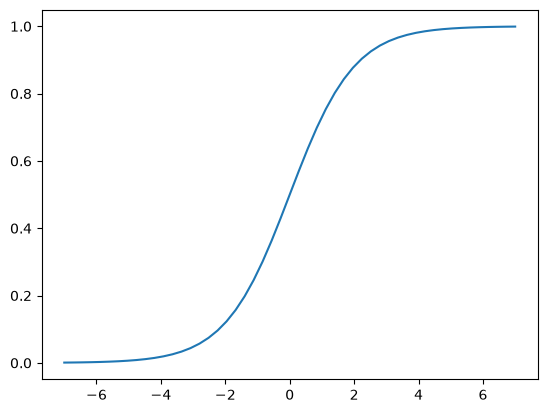

In [328]:
# plt.plot(x, y): 선 그래프. S자 곡선이 0에서 1로 올라가는지 볼 때 쓴다.
plt.plot(z, sigmoid(z))


In [329]:
# 선형 회귀 점수를 손으로 쓴 개념 코드다. 가중합 + 절편.
# 이 셀을 지금 실행하면 w0, w 가 아직 없어서 NameError 가 난다. (작은 모델을 학습한 뒤에 생긴다)
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    return result


In [330]:
# 로지스틱 회귀: 선형 점수에 sigmoid를 씌워 확률을 낸다. 선형회귀와의 차이점이다.
# 마찬가지로 지금은 w0/w가 없으면 NameError. 학습 후 intercept_/coef_ 가 그 역할을 한다.
def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result


## 3.10 Training logistic regression with Scikit-Learn

* Train a model with Scikit-Learn
* Apply it to the validation dataset
* Calculate the accuracy

In [331]:
# LogisticRegression: sklearn이 구현한 로지스틱 회귀 분류기다. 내부에서 시그모이드+가중치 학습을 한다.
from sklearn.linear_model import LogisticRegression


In [332]:
# solver='lbfgs': 가중치를 찾는 최적화 알고리즘. 최근 sklearn 기본값이다.
# max_iter=1000: 최대 반복 횟수. 기본 100이면 이 데이터에서 종종 수렴을 못 한다.
# ConvergenceWarning은 오류가 아니다. fit은 끝났고 예측은 나온다. 반복만 더 필요하다는 경고다.
model = LogisticRegression(solver='lbfgs', max_iter=1000)
# fit(X, y): 특성 X와 정답 y로 가중치를 배울 때 쓴다. 학습 후에 intercept_와 coef_가 채워진다.
model.fit(X_train, y_train)


E:\IT_SPACES\AI\ZoomCamp\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [333]:
# intercept_: 절편 w0. 특성이 모두 0일 때의 기준(로그오즈).
# [0]은 이진 분류에서 '클래스 1(이탈)'에 해당하는 값이다.
model.intercept_[0]


np.float64(-0.12270677138774438)

In [334]:
# coef_: 특성별 가중치. 양수면 그 특성이 클수록 이탈 쪽으로, 음수면 유지 쪽으로.
# round(3): 소수 셋째 자리로 반올림해 읽기 쉽게 할 때 쓴다.
model.coef_[0].round(3)


array([ 0.631, -0.017, -0.73 , -0.024, -0.092,  0.056, -0.106, -0.066,
       -0.038, -0.078, -0.363,  0.353, -0.106,  0.001, -0.246,  0.124,
        0.006,  0.06 , -0.106, -0.07 ,  0.228, -0.106, -0.238, -0.241,
        0.125, -0.123,  0.007, -0.093, -0.045,  0.071, -0.049,  0.124,
       -0.24 ,  0.193, -0.103, -0.106,  0.093, -0.064, -0.106,  0.054,
        0.179, -0.106, -0.189, -0.068,  0.   ])

In [335]:
# predict_proba(X): 각 클래스 확률. 열 0 = 유지(0) 확률, 열 1 = 이탈(1) 확률.
# [:, 1]: 모든 행의 '이탈 확률'만 꺼낸다. 이게 모델의 핵심 출력이다.
y_pred = model.predict_proba(X_val)[:, 1]


In [336]:
# threshold(임계값) 0.5: 확률이 0.5 이상이면 이탈로 예측, 미만이면 유지.
# 확률을 0/1 결정으로 바꾸는 기준이다. 나중에 다른 값으로 바꿀 수 있다.
churn_decision = (y_pred >= 0.5)


In [337]:
# 예측과 실제가 같은 비율 = accuracy(정확도).
# 주의: 이탈이 27%뿐이면 '전부 유지'라고만 해도 약 73%가 나온다. accuracy만 보면 안 되는 이유다.
(y_val == churn_decision).mean()


np.float64(0.8062455642299503)

In [338]:
# 확률·예측·실제를 한 표로 모아 눈으로 대조할 때 DataFrame을 쓴다.
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
# astype(int): True/False를 1/0으로. df['열'] 은 점(.) 대신 문자열 이름으로 열에 접근할 때 쓴다.
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val


In [339]:
# 예측==실제 이면 True. 맞힌 여부 열을 만들 때 쓴다.
df_pred['correct'] = df_pred.prediction == df_pred.actual


In [340]:
# True를 1로 평균내면 정확도와 같다. 위 셀 (y_val == churn_decision).mean()과 같아야 한다.
df_pred.correct.mean()


np.float64(0.8062455642299503)

In [341]:
# 불리언 예측을 0/1 배열로 바꿔 형태만 확인한다.
churn_decision.astype(int)


array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

## 3.11 Model interpretation

* Look at the coefficients
* Train a smaller model with fewer features

In [342]:
# zip 예제. 다음 셀에서 '특성 이름 리스트'와 '가중치 배열'을 같은 방식으로 짝짓는다.
a = [1, 2, 3, 4]
b = 'abcd'


In [343]:
# zip(a,b): 같은 위치끼리 짝. dict()로 맵을 만들 때 쓴다. {1:'a', 2:'b', ...}
dict(zip(a, b))


{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [344]:
# get_feature_names_out(): 원-핫된 열 이름들. coef_와 순서가 같다.
# 예: contract=month-to-month 가중치가 양수면 월간 계약이 이탈 확률을 올린다.
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))


{'contract=month-to-month': np.float64(0.631),
 'contract=one_year': np.float64(-0.017),
 'contract=two_year': np.float64(-0.73),
 'dependents=no': np.float64(-0.024),
 'dependents=yes': np.float64(-0.092),
 'deviceprotection=no': np.float64(0.056),
 'deviceprotection=no_internet_service': np.float64(-0.106),
 'deviceprotection=yes': np.float64(-0.066),
 'gender=female': np.float64(-0.038),
 'gender=male': np.float64(-0.078),
 'internetservice=dsl': np.float64(-0.363),
 'internetservice=fiber_optic': np.float64(0.353),
 'internetservice=no': np.float64(-0.106),
 'monthlycharges': np.float64(0.001),
 'multiplelines=no': np.float64(-0.246),
 'multiplelines=no_phone_service': np.float64(0.124),
 'multiplelines=yes': np.float64(0.006),
 'onlinebackup=no': np.float64(0.06),
 'onlinebackup=no_internet_service': np.float64(-0.106),
 'onlinebackup=yes': np.float64(-0.07),
 'onlinesecurity=no': np.float64(0.228),
 'onlinesecurity=no_internet_service': np.float64(-0.106),
 'onlinesecurity=yes': 

In [345]:
# 해석이 쉽도록 특성 세 개만 쓰는 작은 모델. 계약, 가입개월, 월요금.
small = ['contract', 'tenure', 'monthlycharges']


In [346]:
# iloc[:10]: 위치 기준으로 앞 10행. to_dict(orient='records')는 DictVectorizer 입력 모양이다.
df_train[small].iloc[:10].to_dict(orient='records')


[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [347]:
# 축소 특성만으로 train/val 전체를 딕셔너리 리스트로 만든다.
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')


In [348]:
# 큰 모델의 dv와 섞이지 않게 작은 벡터라이저를 따로 만든다.
dv_small = DictVectorizer(sparse=False)
# fit만: 규칙(contract의 범주들)만 배운다. 아직 행렬 X는 안 만든다.
dv_small.fit(dicts_train_small)


DictVectorizer(sparse=False)

In [349]:
# 학습된 특성 이름. month-to-month / one_year / two_year 원-핫 + 숫자 두 개.
dv_small.get_feature_names_out()


array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [350]:
# transform: 이미 fit한 규칙으로 숫자 행렬을 만들 때. fit과 분리한 예.
X_train_small = dv_small.transform(dicts_train_small)


In [351]:
# 축소 특성으로 로지스틱 회귀 학습. 여기서 나온 w0, w 를 위의 개념 함수가 쓸 수 있다.
model_small = LogisticRegression(solver='lbfgs', max_iter=1000)
model_small.fit(X_train_small, y_train)


LogisticRegression(max_iter=1000)

In [352]:
# 작은 모델의 절편. 이제 linear_regression / logistic_regression 의 w0 가 생긴다.
w0 = model_small.intercept_[0]
w0


np.float64(-2.477957596026966)

In [353]:
# 작은 모델의 가중치 벡터 w. 개념 함수의 NameError가 해소된다.
# 모델 학습을 통해 도출된 가중치 벡터 w 확인. 이 단계에서 필요한 함수나 변수 선언이 완료되어 코드 실행 준비가 끝남.
w = model_small.coef_[0]
w.round(3)


array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [354]:
# 축소 모델: month-to-month는 보통 +, two_year는 - (장기 계약일수록 이탈↓).
dict(zip(dv_small.get_feature_names_out(), w.round(3)))


{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [355]:
# 강의는 이 벡터를 안 보여주고 손계산으로 바로 간다.
# 아래가 그 예시 고객을 DictVectorizer가 0/1(+숫자)로 바꾼 결과다.
example = {'contract': 'two_year', 'monthlycharges': 30, 'tenure': 24}
x = dv_small.transform([example])[0]
list(zip(dv_small.get_feature_names_out(), x))
# 2년 계약이면 month-to-month=0, one_year=0, two_year=1 이라
# 0.971과 -0.024는 곱하면 0이다. 빠진 게 아니라 이 고객에선 항이 꺼진 것이다.

[('contract=month-to-month', np.float64(0.0)),
 ('contract=one_year', np.float64(0.0)),
 ('contract=two_year', np.float64(1.0)),
 ('monthlycharges', np.float64(30.0)),
 ('tenure', np.float64(24.0))]

In [356]:
# 강의 손계산 예시: 2년 계약(two_year≈-0.949) + 월요금 30 + 가입 24개월.
# 원-핫이라 계약 더미는 하나만 1이다. 월간(0.971)·1년(-0.024)은 이 고객에선 0.
# 1년 계약 고객이면 가운데가 (-0.024)가 되고, 월간이면 (+0.971)이다.
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [373]:
# _: 바로 위 셀의 출력값. sigmoid(_)는 그 선형 점수를 이탈 확률(0~1)로 바꿀 때 쓴다.
sigmoid(_)


np.float64(0.7310585786300049)

## 3.12 Using the model

In [358]:
# 최종 모델은 테스트를 남겨 두고 train+val(full_train)로 다시 배운다.
# 데이터가 많을수록 규칙이 조금 더 안정적이다. 테스트는 아직 안 넣는다.
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')


In [359]:
# 벡터라이저를 새로 만들어 full_train으로 인코딩 규칙을 다시 fit 한다.
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)


In [360]:
# full_train에는 EDA용으로 churn 열이 아직 있다. .values로 타깃 배열 y를 만든다.
# (df_train에서는 이미 del 로 지웠다.)
y_full_train = df_full_train.churn.values


In [361]:
# 최종 로지스틱 회귀. ConvergenceWarning은 여전히 경고일 뿐 셀 실패가 아니다.
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_full_train, y_full_train)


E:\IT_SPACES\AI\ZoomCamp\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [362]:
# 테스트 고객도 같은 열만 딕셔너리로. 학습에 안 쓴 사람들이 최종 시험이다.
dicts_test = df_test[categorical + numerical].to_dict(orient='records')


In [364]:
# 테스트는 fit 하지 않는다. full_train으로 배운 dv로만 transform.
# 테스트에 맞춰 범주를 다시 배우면 점수가 가짜로 좋아진다.
X_test = dv.transform(dicts_test)


In [365]:
# 테스트 세트 이탈 확률. [:,1] = 클래스 1.
y_pred = model.predict_proba(X_test)[:, 1]


In [366]:
# 검증 때와 같은 임계값 0.5로 이탈/유지를 나눈다.
churn_decision = (y_pred >= 0.5)


In [367]:
# 테스트 accuracy. 검증과 비슷하면 과적합이 심하지 않다는 신호다.
# 테스트는 마지막에 한 번만 보는 이유: 여러 번 보면 테스트에 맞춰 모델을 고치게 된다.
(churn_decision == y_test).mean()


np.float64(0.8097941802696949)

In [368]:
# 테스트 정답 배열 전체. 다음에서 마지막 고객 실제값과 비교할 기준.
y_test


array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [369]:
# [-1]: 리스트의 마지막 원소. 고객 한 명에 대해 모델이 어떻게 쓰이는지 보여 주는 예.
customer = dicts_test[-1]
customer


{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [370]:
# 한 명도 [customer]처럼 리스트로 감싼다. DictVectorizer는 '행들의 목록'을 기대한다.
X_small = dv.transform([customer])


In [371]:
# [0, 1]: 첫 번째(유일한) 행, 이탈 클래스 확률. 이 고객의 예측 이탈 확률이다.
model.predict_proba(X_small)[0, 1]


np.float64(0.6381019047535099)

In [372]:
# 그 고객의 실제 이탈 여부. 확률과 나란히 보면 맞혔는지 알 수 있다.
y_test[-1]


np.int64(1)

## 3.13 Summary

* Feature importance - risk, mutual information, correlation
* One-hot encoding can be implemented with `DictVectorizer`
* Logistic regression - linear model like linear regression
* Output of log reg - probability
* Interpretation of weights is similar to linear regression

## 3.14 Explore more

More things

* Try to exclude least useful features


Use scikit-learn in project of last week

* Re-implement train/val/test split using scikit-learn in the project from the last week
* Also, instead of our own linear regression, use `LinearRegression` (not regularized) and `RidgeRegression` (regularized). Find the best regularization parameter for Ridge

Other projects

* Lead scoring - https://www.kaggle.com/ashydv/leads-dataset
* Default prediction - https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

